# Notebook 3 — EDA with Data Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('spacex_launches_raw.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

### Flight number vs. launch site

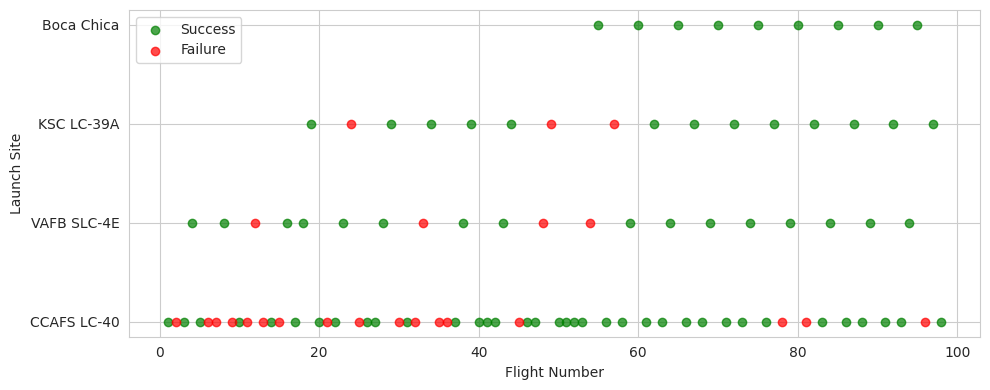

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
for cls, color, label in [(1, 'green', 'Success'), (0, 'red', 'Failure')]:
    s = df[df['Class'] == cls]
    ax.scatter(s['Flight_Number'], s['Launch_Site'], c=color, label=label, alpha=0.7)
ax.set_xlabel('Flight Number'); ax.set_ylabel('Launch Site'); ax.legend()
plt.tight_layout(); plt.show()

### Success rate by launch site

In [3]:
site = (df.groupby('Launch_Site')['Class'].agg(['count', 'sum', 'mean']))
site['rate_%'] = (site['mean'] * 100).round(1)
print(site[['count', 'sum', 'rate_%']])

             count  sum  rate_%
Launch_Site                    
Boca Chica       9    9   100.0
CCAFS LC-40     53   36    67.9
KSC LC-39A      16   13    81.2
VAFB SLC-4E     20   16    80.0


### Success rate by orbit type

            count  sum  rate_%
Orbit_Type                    
GEO            16   15    93.8
ISS            16   15    93.8
LEO            42   35    83.3
SSO            16    7    43.8
HEO             8    2    25.0


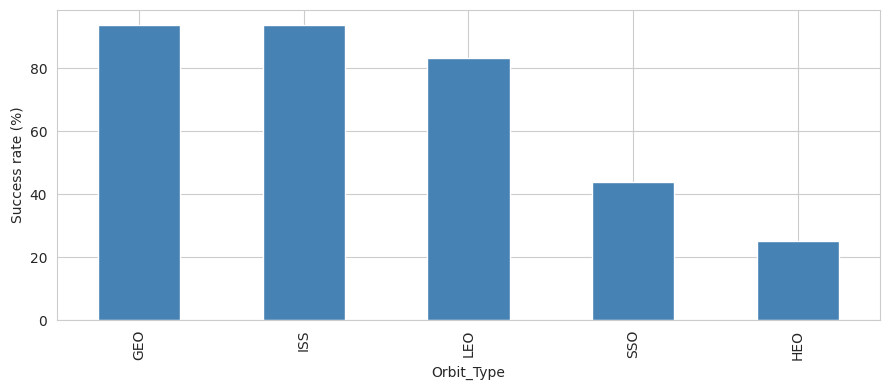

In [4]:
orbit = (df.groupby('Orbit_Type')['Class'].agg(['count', 'sum', 'mean']))
orbit['rate_%'] = (orbit['mean'] * 100).round(1)
print(orbit[['count', 'sum', 'rate_%']].sort_values('rate_%', ascending=False))

fig, ax = plt.subplots(figsize=(9, 4))
orbit['rate_%'].sort_values(ascending=False).plot.bar(ax=ax, color='steelblue')
ax.set_ylabel('Success rate (%)')
plt.tight_layout(); plt.show()

### Payload mass vs. outcome

In [5]:
print('Average payload (successful):', int(df[df.Class==1].Payload_Mass_kg.mean()), 'kg')
print('Average payload (failed):    ', int(df[df.Class==0].Payload_Mass_kg.mean()), 'kg')

Average payload (successful): 3697 kg
Average payload (failed):     4282 kg


### Booster experience vs. success

In [6]:
exp = pd.cut(df['Booster_Landings'], bins=[-1, 0, 2, 6], labels=['0 (new)', '1-2', '3+'])
print((df.groupby(exp)['Class'].mean() * 100).round(0).astype(int).astype(str) + '%')

Booster_Landings
0 (new)     51%
1-2         83%
3+         100%
Name: Class, dtype: str


### Yearly success trend

In [7]:
yearly = (df.groupby('Year')['Class'].mean() * 100).round(0)
print(yearly.astype(int).astype(str) + '%')
for lo, hi in [(2015, 2016), (2017, 2019), (2020, 2023)]:
    sub = df[(df.Year >= lo) & (df.Year <= hi)]
    print(f'{lo}-{hi}: {sub.Class.mean()*100:.0f}% success over {len(sub)} flights')

Year
2015     75%
2016     42%
2017     75%
2018     58%
2019     75%
2020     83%
2021    100%
2022     85%
2023     89%
Name: Class, dtype: str
2015-2016: 50% success over 16 flights
2017-2019: 69% success over 36 flights
2020-2023: 89% success over 46 flights
